<img src="../images/practicum_ai_logo.png" alt="Practicum AI Logo" align="right" width="250">


# 01: The Language of Life
### Introduction to Biological Language Models (BioLMs)

Welcome to the first step in your journey into **BioAI**. In this notebook, we join **Dr. Aris**, a computational biologist who has spent his career asking one audacious question: *can a machine learn to read the genome the way a linguist reads an ancient text?*

The answer is yes — but only after solving a fundamental translation problem. Before any Transformer, Mamba, or Hyena model can predict a mutation or identify a promoter, it needs a way to convert **chemical sequences** into **numerical vectors** that a neural network can process. That translation is what this notebook is about.

---
### 🎯 Learning Objectives
1. **The Alphabet of Life** — understand the mathematical difference between DNA (4 letters) and proteins (20 letters)
2. **Tokenization** — implement k-mer sliding windows and discover why AI prefers to learn its own token boundaries
3. **BPE (Byte Pair Encoding)** — see how modern models learn biologically meaningful sub-words from data
4. **Embeddings** — visualize how a pretrained model maps biological sequences into geometric meaning
5. **Information Density** — quantify why protein embeddings cluster more tightly than DNA embeddings

### 🧬 The Big Picture
Every notebook in this series builds on the foundation you establish here. The three pillars — **tokenization**, **embeddings**, and **information density** — explain *why* models make the architectural choices explored in NB02 through NB07.

| Pillar | The question it answers |
|---|---|
| **Tokenization** | How do we break a sequence into learnable pieces? |
| **Embeddings** | How do we give those pieces geometric meaning? |
| **Information density** | Why do DNA and protein models behave so differently? |

Are you ready to help Dr. Aris decode the first sequence?

In [1]:
# Dr. Aris prepares the lab equipment and models
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer, AutoModel, logging
from sklearn.decomposition import PCA
import warnings


# This hides the 'Unexpected Keys' warnings that are normal for BioLMs
logging.set_verbosity_error() 
warnings.filterwarnings("ignore")

# 1. Hardware Check
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"🚀 Dr. Aris is utilizing: {device.upper()}")

# 2. Model Selection
dna_model_name = "zhihan1996/DNA_bert_6"
prot_model_name = "facebook/esm2_t6_8M_UR50D"

print("Loading Interpreters and Model Weights...")
dna_tokenizer = AutoTokenizer.from_pretrained(dna_model_name, trust_remote_code=True)
dna_model = AutoModel.from_pretrained(dna_model_name, trust_remote_code=True).to(device)

prot_tokenizer = AutoTokenizer.from_pretrained(prot_model_name)
prot_model = AutoModel.from_pretrained(prot_model_name).to(device)

print("✅ Lab setup complete! All models loaded cleanly.")

🚀 Dr. Aris is utilizing: CUDA
Loading Interpreters and Model Weights...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

✅ Lab setup complete! All models loaded cleanly.


## 1. The Alphabet of Life

Every language needs an alphabet. Before Dr. Aris can train a model, he must define the vocabulary it will learn from. In biology, there are two fundamentally different scripts — and they create very different challenges for AI.

### 🧬 The DNA Alphabet — 4 letters
`A` Adenine · `C` Cytosine · `G` Guanine · `T` Thymine

DNA is the *storage medium* of the cell — long, repetitive, and redundant by design. With only 4 symbols, a single letter tells a model very little. Meaning lives in *combinations and context*, not in individual characters.

### 🔬 The Protein Alphabet — 20 letters
Twenty amino acids, each with distinct chemical properties: charge, size, hydrophobicity. Proteins are the *workers* of the cell. Every letter is dense with functional information — swap one amino acid and a protein may fold differently, lose its active site, or stop working entirely.

### 🧩 The Mathematical Consequence
Information theory gives us a precise way to measure this difference. Each position carries $\log_2(\text{alphabet size})$ bits of information:

| Molecule | Alphabet size | Bits per position | What this means |
|---|---|---|---|
| DNA | 4 | $\log_2(4) = 2.0$ bits | Low density — meaning requires long context |
| Protein | 20 | $\log_2(20) \approx 4.32$ bits | High density — one amino acid carries a lot |

This 2× density gap shapes every architectural choice we'll encounter in the series. Let's see Dr. Aris implement both alphabets in Python.

In [2]:
# Dr. Aris defines the standard alphabets for our BioAI models

# 🧬 The Genomic Alphabet (DNA)
dna_alphabet = ['A', 'C', 'G', 'T']

# 🧪 The Proteomic Alphabet (Common Amino Acids)
protein_alphabet = [
    'A', 'R', 'N', 'D', 'C', 'E', 'Q', 'G', 'H', 'I', 
    'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V'
]

print(f"DNA Alphabet Size: {len(dna_alphabet)}")
print(f"Protein Alphabet Size: {len(protein_alphabet)}")

# Dr. Aris wants to see the complexity difference for a sequence of length 5
dna_combos = len(dna_alphabet)**5
protein_combos = len(protein_alphabet)**5

print(f"\nPossible 5-letter DNA sequences: {dna_combos:,}")
print(f"Possible 5-letter Protein sequences: {protein_combos:,}")
print(f"\nObservation: The Protein space is {protein_combos/dna_combos:.0f}x more complex than DNA!")

DNA Alphabet Size: 4
Protein Alphabet Size: 20

Possible 5-letter DNA sequences: 1,024
Possible 5-letter Protein sequences: 3,200,000

Observation: The Protein space is 3125x more complex than DNA!


## 2. Tokenization: Breaking the Continuous Script

Biological sequences are **languages without spaces**. Unlike English, where words are separated by gaps, DNA is one unbroken string of A, T, C, G — the AI has no built-in sense of where one 'word' ends and another begins.

Dr. Aris's solution: create our own units, called **tokens**, using purpose-built strategies.

### Strategy A — K-mer Sliding Windows (DNA)

Since individual DNA letters carry only 2 bits of information, we look at overlapping windows of length *k*. A 6-mer window captures enough local context to distinguish functional motifs like the TATA box (`TATAAA`).

```
Sequence:  A T G C A T G C
3-mers:    ATG | TGC | GCA | CAT | ATG | TGC
           └─────── overlapping windows, k=3 ───────┘
```

**Trade-off:** k-mers create massive redundancy (adjacent k-mers share k−1 bases) and the vocabulary grows as $4^k$ — for k=6, that's 4,096 possible tokens.

### Strategy B — Character-Level (Proteins)

Because each amino acid is chemically distinct (~4.32 bits), treating each letter as its own token works well for proteins. This is exactly what ESM-2 does.

### Strategy C — BPE (coming next)

Modern models learn token boundaries from data rather than fixing them by hand. Let's implement k-mer and character tokenization with Dr. Aris first.

In [3]:
# --- DNA Tokenization (The K-mer Method) ---
dna_seq = "ATGCGATCGTAGCTAGCTAG"

def get_kmers(sequence, k=3):
    """Slices DNA into overlapping windows of size k"""
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

# Dr. Aris wants to compare 3-mers vs 6-mers
dna_3mers = get_kmers(dna_seq, k=3)
dna_6mers = get_kmers(dna_seq, k=6)

print("🧬 DNA Sequence:", dna_seq)
print(f"🧬 3-mer Tokens (Count: {len(dna_3mers)}):", dna_3mers[:5], "...")
print(f"🧬 6-mer Tokens (Count: {len(dna_6mers)}):", dna_6mers[:5], "...")

# --- Protein Tokenization (The Character Method) ---
protein_seq = "MVLSPADKTNVKAAWG"
protein_tokens = [aa for aa in protein_seq]

print("\n🧪 Protein Sequence:", protein_seq)
print(f"🧪 Protein Tokens (Count: {len(protein_tokens)}):", protein_tokens[:8], "...")

🧬 DNA Sequence: ATGCGATCGTAGCTAGCTAG
🧬 3-mer Tokens (Count: 18): ['ATG', 'TGC', 'GCG', 'CGA', 'GAT'] ...
🧬 6-mer Tokens (Count: 15): ['ATGCGA', 'TGCGAT', 'GCGATC', 'CGATCG', 'GATCGT'] ...

🧪 Protein Sequence: MVLSPADKTNVKAAWG
🧪 Protein Tokens (Count: 16): ['M', 'V', 'L', 'S', 'P', 'A', 'D', 'K'] ...


## 3. Learned Tokens: Byte Pair Encoding (BPE)

Manual k-mers have a fundamental flaw: they use the *same window everywhere*, regardless of whether the region is functionally critical or repetitive noise. The TATA box `TATAAA` deserves to be one token; a random `ACGTACGT` repeat probably doesn't.

**Byte Pair Encoding (BPE)** solves this by *learning* token boundaries from data:

1. Start with a character-level vocabulary: `{A, T, C, G}`
2. Find the most frequent adjacent pair (e.g., `AT` appears 847,000 times per chromosome)
3. Merge it into a new token: `AT`
4. Repeat until the vocabulary reaches the target size (~4,096 tokens)

The result: **biologically frequent motifs become single tokens**. The TATA box appears hundreds of thousands of times in the human genome — BPE naturally discovers and merges it. A rare sequence falls back to individual characters.

### Why BPE Beats Fixed K-mers

| Property | Fixed 6-mer | BPE |
|---|---|---|
| Token boundaries | Fixed (every 6 bases) | Learned from genomic frequency |
| Handles rare sequences | Forces into vocabulary | Falls back to characters |
| Motif alignment | Accidental | Intentional |
| Sequence length after tokenizing | Always longer | Often shorter |

We use the real tokenizers from **DNABERT** (6-mer) and **ESM-2** (character-level) to compare both strategies on the same sequences.

In [4]:
# --- Testing the AI's Vocabulary ---

# Sample Sequences
sample_dna = "ATGCGTACGTAGCTAGCTAGCTAGCGATCGATCG"
sample_prot = "MVLSPADKTNVKAAWGKVGAHAGEYGAEALER"

# DNA Tokenization: DNABERT (6-mer version) expects space-separated 6-mers
dna_formatted = " ".join([sample_dna[i:i+6] for i in range(len(sample_dna) - 6 + 1)])
dna_tokens = dna_tokenizer.tokenize(dna_formatted)
dna_ids = dna_tokenizer.encode(dna_formatted)

# Protein Tokenization: ESM-2
prot_tokens = prot_tokenizer.tokenize(sample_prot)
prot_ids = prot_tokenizer.encode(sample_prot)

print("--- DNABERT (DNA 6-mer) ---")
print(f"Learned Tokens: {dna_tokens[:5]}...")
print(f"Numerical IDs:  {dna_ids[:5]}...")

print("\n--- ESM-2 (Protein) ---")
print(f"Learned Tokens: {prot_tokens[:10]}...")
print(f"Numerical IDs:  {prot_ids[:10]}...")

--- DNABERT (DNA 6-mer) ---
Learned Tokens: ['ATGCGT', 'TGCGTA', 'GCGTAC', 'CGTACG', 'GTACGT']...
Numerical IDs:  [2, 498, 1977, 3799, 2896]...

--- ESM-2 (Protein) ---
Learned Tokens: ['M', 'V', 'L', 'S', 'P', 'A', 'D', 'K', 'T', 'N']...
Numerical IDs:  [0, 20, 7, 4, 8, 14, 5, 13, 15, 11]...


### 🔢 From Words to Numbers: Understanding Token IDs

The tokenizer's job is only half done once it splits a sequence into tokens. The next step: convert every token to an **integer ID** — the address of that token in the model's internal vocabulary dictionary.

**Why integers?** Neural networks are matrix multiplication machines. They need numbers, not strings. Each ID is a row index into the model's **embedding matrix** — the lookup table that converts a discrete token into a dense, continuous vector.

```
'TATAAA'  →  tokenizer  →  ID: 3218  →  embedding matrix row 3218  →  [0.12, -0.45, 0.33, ...]
                                         (W_embed ∈ ℝ^{V × d})           (d = 768 dimensions)
```

**What the numbers tell us:**
- DNA 6-mer IDs span up to 4,096 — the full k-mer vocabulary
- Protein character IDs are compact (only 20–25 amino acids plus special tokens)

This vocabulary size difference is one reason protein models can be more parameter-efficient than DNA models at the same hidden dimension — they need a smaller embedding table.

Now that we've turned life into numbers, let's give those numbers *meaning*.

> ### 🛠️ Mini Task 1: The Efficiency Challenge
>
> Dr. Aris claims BPE is more efficient than manual k-mers. Let's verify.
> When we applied 3-mers to our 34-base DNA sequence, we generated **32 tokens**.
>
> **Your tasks:**
> 1. In the code cell below, count how many tokens `dna_tokenizer` created for the same sequence. Use `len(dna_tokens)` and print the result.
> 2. Compute the **compression ratio**: `32 / bpe_count`. A value > 1 means BPE is more compact.
> 3. In a new markdown cell, write 2–3 sentences explaining: if BPE produces fewer tokens, does that make the model's job easier or harder? Consider what each token has to 'represent.'
>
> *Hint: `len(list_name)` counts elements in a Python list.*

In [5]:
# --- YOUR TASK ---
# 1. Count the BPE tokens from our dna_tokens list
# bpe_token_count = len(dna_tokens)

# 2. Compare it to our manual count
# kmer_token_count = 32 

# 3. Print the results!
# print(f"Manual Count: {kmer_token_count}")
# print(f"AI BPE Count: {bpe_token_count}")

# 4. Efficiency Factor
# print(f"The AI is {kmer_token_count / bpe_token_count:.2f}x more efficient!")

## 4. Embeddings: Turning Tokens into Meaning

We have integer IDs. But `3218` carries no biological meaning on its own — to a neural network, it's just a number. How does the model learn that token 3218 (representing the k-mer `TATAAA`) is related to gene transcription initiation?

### The Embedding Matrix

Every model contains an **embedding matrix** $W_e \in \mathbb{R}^{V \times d}$, where $V$ is vocabulary size and $d$ is the hidden dimension (typically 768). Token ID `3218` selects row 3218 — a 768-dimensional vector. During pretraining on millions of sequences, these vectors are adjusted by gradient descent until tokens that *behave similarly in biological context* end up close together in this high-dimensional space.

### The Latent Space

The result is a **Latent Space** — a geometric map of biological meaning:

- **Distance** ≈ biological dissimilarity
- **Clusters** = functional neighborhoods (all promoter k-mers cluster; all stop codons cluster)
- **Directions** = learned biological gradients (moving along one axis may increase GC content)

We can't visualize 768 dimensions directly, but **PCA** or **UMAP** can project them down to 2D. Let's extract real embeddings from DNABERT and ESM-2 and plot Dr. Aris's latent map.

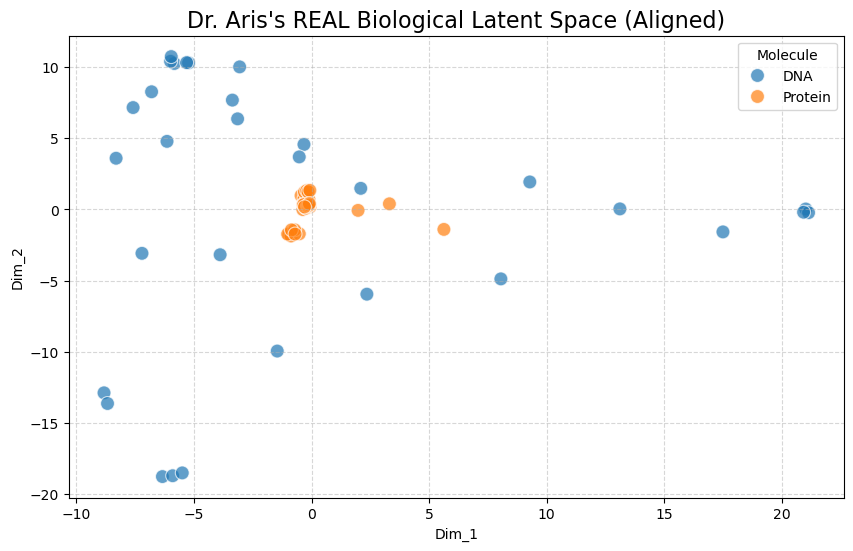

DNA Embedding Size: 768 dimensions
Protein Embedding Size: 320 dimensions


In [6]:
# --- Extracting REAL Embeddings ---
# We pass the IDs through the model "brains" to get the actual vectors

# Prepare inputs as tensors
dna_tensor = torch.tensor([dna_ids]).to(device)
prot_tensor = torch.tensor([prot_ids]).to(device)

# Get the vectors from the last layer of the models
with torch.no_grad():
    dna_out = dna_model(dna_tensor).last_hidden_state[0].cpu().numpy()
    prot_out = prot_model(prot_tensor).last_hidden_state[0].cpu().numpy()

# Alignment: Because DNA is 768-dim and Protein is 320-dim, 
# we reduce them to 2D individually before combining.
pca_dna = PCA(n_components=2)
pca_prot = PCA(n_components=2)

dna_2d = pca_dna.fit_transform(dna_out)
prot_2d = pca_prot.fit_transform(prot_out)

# Combine the 2D results
combined_coords = np.vstack([dna_2d, prot_2d])

# Organize into a DataFrame
df = pd.DataFrame(combined_coords, columns=['Dim_1', 'Dim_2'])
df['Molecule'] = ['DNA'] * len(dna_out) + ['Protein'] * len(prot_out)

# --- Plotting the REAL Map ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Dim_1', y='Dim_2', hue='Molecule', s=100, alpha=0.7)
plt.title("Dr. Aris's REAL Biological Latent Space (Aligned)", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"DNA Embedding Size: {dna_out.shape[1]} dimensions")
print(f"Protein Embedding Size: {prot_out.shape[1]} dimensions")

### 🗺️ Interpreting the Map: Geometry as Biology

You've just visualized real biological knowledge extracted from two state-of-the-art models. Every point on this map is a token; every distance is a learned relationship.

**What to look for in the plot:**

- **Protein cluster (orange):** ESM-2's amino acid embeddings are tightly packed. Each amino acid has a specific, well-defined chemical role — the model learned to encode chemically similar amino acids near each other in the latent space.

- **DNA dispersion (blue):** DNABERT's 6-mer embeddings are more spread out. DNA is highly context-dependent — the same 6-mer can function as a promoter element in one gene and repetitive noise in another. The model encodes this ambiguity with a wider, more diffuse distribution.

- **Separation between clusters:** The protein and DNA clouds are separated. The models have learned that amino acid tokens and nucleotide k-mers are fundamentally different types of biological objects.

> ### 💡 Dr. Aris's Insight
> *"What you are looking at is not a simulation — it is a window into what the model believes about biology. Every cluster, every gap, every outlier is something real that the model learned from millions of sequences. The geometry* **is** *the knowledge."*

**Key takeaway:** You didn't generate synthetic embeddings — you extracted actual pretrained representations from world-class biological AI. The 2D map you see is the model's compressed world-model of molecular biology.

## 5. Information Density: Why the Map Looks Different

Dr. Aris wants to put a precise number on what we just observed. Why do protein embeddings cluster so tightly while DNA embeddings spread out? The answer is **information density** — how much information is packed into each position.

### Shannon Information Content

For a sequence drawn uniformly from an alphabet of size $k$, each position carries exactly $\log_2(k)$ bits of information:

| Molecule | Alphabet size | Bits per position | What this means for AI |
|---|---|---|---|
| DNA | 4 | $\log_2(4) = 2.0$ bits | Low density — long context needed to find signal |
| Protein | 20 | $\log_2(20) \approx 4.32$ bits | High density — single amino acids are informative |

### Practical Consequences

This 2× information gap has cascading effects throughout BioAI:

1. **DNA models need longer context** — because each base contributes little, the model needs to see many bases together to detect a functional signal. This is why k-mers, BPE, and long-context architectures (NB04, NB05) are necessary for DNA.

2. **Protein models generalize from fewer examples** — a single amino acid substitution changes a token's position substantially in the latent space. Models learn richer per-position representations.

3. **DNA redundancy is a biological feature** — the genetic code maps 64 codons to only 20 amino acids. Most amino acids are encoded by 2–6 different codons. A random single-nucleotide change is often *silent* — the same protein is produced. This built-in redundancy has protected the genetic code for 3.8 billion years.

In [7]:
import math

# Dr. Aris calculates the Shannon Entropy (Information Capacity) per position
bits_dna = math.log2(len(dna_alphabet))
bits_prot = math.log2(len(protein_alphabet))

print(f"🧬 DNA Information Density: {bits_dna:.2f} bits per base")
print(f"🧪 Protein Information Density: {bits_prot:.2f} bits per amino acid")

# Dr. Aris's Density Comparison
density_ratio = bits_prot / bits_dna
print(f"\n🔬 Conclusion: Proteins are {density_ratio:.2f}x more information-dense than DNA.")
print("This is why the Protein clusters in our map are often more distinct and functionally 'packed'!")

🧬 DNA Information Density: 2.00 bits per base
🧪 Protein Information Density: 4.32 bits per amino acid

🔬 Conclusion: Proteins are 2.16x more information-dense than DNA.
This is why the Protein clusters in our map are often more distinct and functionally 'packed'!


> ### 💡 Dr. Aris's Insight: Redundancy as Error Correction
>
> *"DNA's low information density is not a weakness — it is an ancient engineering solution. The genetic code maps 64 codons (4³ triplets) to only 20 amino acids. Most amino acids are encoded by 2–6 different codons, so most mutations are silent. This redundancy has protected life's blueprints for 3.8 billion years.*
>
> *Proteins cannot afford the same luxury. With 4.32 bits per position, changing one amino acid substantially shifts a token's coordinate in the latent space — which is precisely why missense mutations cause disease. Biological information density and disease risk are two sides of the same mathematical coin."*

---
## Summary

Congratulations — you've laid the foundation that every other notebook in this series builds on. Dr. Aris now has everything he needs to feed biological sequences into an AI:

| Concept | What we learned | Why it matters downstream |
|---|---|---|
| **Alphabet** | DNA = 4 letters, Protein = 20 | Determines information density and model design |
| **K-mer tokenization** | Overlapping windows of size k | Captures local context; creates redundancy |
| **BPE tokenization** | Learned token boundaries from frequency | Aligns naturally with biological motifs |
| **Embeddings** | High-dimensional geometric meaning space | Distance = biological (dis)similarity |
| **Information density** | DNA: 2 bits/pos, Protein: 4.32 bits/pos | Explains clustering in latent space |

### 🛠️ Mini Task 2: Predict Before You Observe

> Based on what you've learned about information density, make a written prediction before running Notebook 03: if you train a DNA model and a protein model each on the same number of labeled examples, which one do you expect to achieve higher accuracy first, and why? Write your reasoning in a new markdown cell. Reference bits-per-position and sequence length in your answer. Come back to this prediction after completing NB03 and NB07 to see if you were right.

---

**What's Next:** In **Notebook 02**, Dr. Aris explores the three model architectures that process these embeddings — Transformers, Mamba, and Hyena — and confronts the scaling problem that makes genomic AI so architecturally interesting.

---
## Push Your Work to GitHub
<img src="../images/push_to_github.png" alt="Push to GitHub" align="right" width="150">

Save your progress:
1. `Ctrl+S` / `Cmd+S` to save the notebook
2. Stage → Commit → Push using the Git extension

**Suggested commit message:** `feat: NB01 — tokenization, embeddings, information density`